# Q6.
```{admonition}
:class: note
It is claimed that in the case of data that is just barely linearly separable, a support vector classifier with a small value of `C` that misclassifies a couple of training observations may perform better on test data than one with a huge value of `C` that does not misclassify any training observations. You will now investigate this claim.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

## (a)
```{admonition}
:class: note
Generate two-class data with $p = 2$ in such a way that the classes are just barely linearly separable.

In [4]:
rng = np.random.default_rng(1728)
x1 = rng.normal(0,1,size=100)
x21 = rng.normal(2,1,size=50)
x22 = rng.normal(-2,1,size=50)
x2 = np.hstack([x21,x22])

classes = (x2<0).astype(int)

df = pd.DataFrame({'x1':x1,'x2':x2,'class':classes})

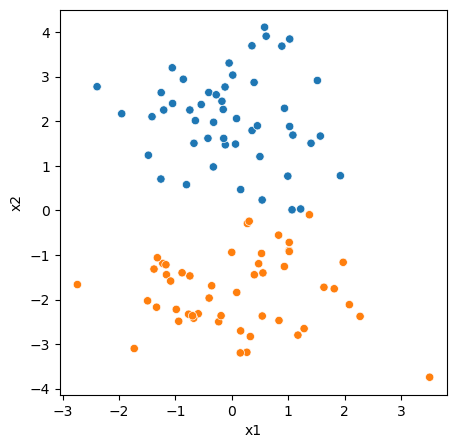

In [5]:
plt.figure(figsize=(5,5))
sns.scatterplot(data=df,x='x1',y='x2',hue='class',legend=False)
plt.show()

## (b)
```{admonition}
:class: note
Compute the cross-validation error rates for support vector classifiers with a range of `C` values. How many training observations are misclassified for each value of `C` considered, and how does this relate to the cross-validation errors obtained

In [13]:
Cs = np.logspace(-3,3,10)
errors = []
models = []
cv = KFold(n_splits=5,shuffle=True,random_state=1728)
for C in Cs:
    svc_model = svm.SVC(kernel='linear',C=C)
    mean_cvs_error = np.mean(1-cross_val_score(svc_model,df[['x1','x2']],df['class'],scoring='accuracy',cv=cv))
    svc_model.fit(df[['x1','x2']],df['class'])
    models.append(svc_model)
    error_rate = 1-accuracy_score(svc_model.predict(df[['x1','x2']]),df['class'])
    errors.append([mean_cvs_error,error_rate])
print('    '+'C'+'     '+'CV error'+'     '+'Train error')
for i,e in enumerate(errors):
    print(f'{Cs[i]:.1E}'+'     '+f'{errors[i][0]:.3f}'+'         '+f'{errors[i][1]:.3f}')

    C     CV error     Train error
1.0E-03     0.490         0.020
4.6E-03     0.020         0.010
2.2E-02     0.030         0.020
1.0E-01     0.030         0.020
4.6E-01     0.000         0.000
2.2E+00     0.020         0.010
1.0E+01     0.020         0.010
4.6E+01     0.010         0.000
2.2E+02     0.010         0.000
1.0E+03     0.010         0.000


## (c)
```{admonition}
:class: note
Generate an appropriate test data set, and compute the test errors corresponding to each of the values of `C` considered. Which value of `C` leads to the fewest test errors, and how does this compare to the values of `C` that yield the fewest training errors and the fewest cross-validation errors?

In [14]:
x1t = rng.normal(0,1,size=1000)
x21t = rng.normal(2,1,size=500)
x22t = rng.normal(-2,1,size=500)
x2t = np.hstack([x21t,x22t])

classes = (x2t<0).astype(int)

dft = pd.DataFrame({'x1':x1t,'x2':x2t,'class':classes})

In [15]:
test_errors = []
for i,C in enumerate(Cs):
    test_errors.append(1-accuracy_score(models[i].predict(dft[['x1','x2']]),dft['class']))
best_test_C = Cs[np.argmin(test_errors)]
best_test_error = np.min(test_errors)
print(f'Best test error was {best_test_error:.3f} using C = {best_test_C:.1E}')

Best test error was 0.001 using C = 4.6E-03


## (d)
```{admonition}
:class: note
Discuss your results.

Choosing a smaller `C = 0.0046...` value lead to improved test performance despite the training and CV error being lowest near this `C`.